In [1]:
import pandas as pd
import numpy as np
import os
import random
import tensorflow as tf
import cv2
from tqdm import tqdm
from tensorflow.keras import callbacks
from tensorflow.keras import layers, Model


from  matplotlib import pyplot as plt
import matplotlib.image as mpaimg
from IPython.display import clear_output
%matplotlib inline

from IPython.display import HTML
from base64 import b64encode

In [2]:
# Load directories
train_data_dir = "../input/datasets/sakshaymahna/kittiroadsegmentation/training/image_2/"
train_gt_dir = "../input/datasets/sakshaymahna/kittiroadsegmentation/training/gt_image_2/"

test_data_dir = "../input/datasets/sakshaymahna/kittiroadsegmentation/testing/"

In [3]:
print("Training images:")
print(os.listdir(train_data_dir)[:10])

print("\nGround truth:")
print(os.listdir(train_gt_dir)[:10])

print("\nTesting:")
print(os.listdir(test_data_dir)[:10])

Training images:
['umm_000040.png', 'uu_000047.png', 'umm_000034.png', 'umm_000006.png', 'uu_000001.png', 'uu_000038.png', 'umm_000095.png', 'uu_000027.png', 'uu_000035.png', 'umm_000023.png']

Ground truth:
['um_lane_000024.png', 'um_lane_000090.png', 'umm_road_000059.png', 'um_road_000053.png', 'um_lane_000052.png', 'um_road_000060.png', 'uu_road_000081.png', 'uu_road_000056.png', 'um_road_000001.png', 'uu_road_000015.png']

Testing:
['challenge.mp4', 'harder_challenge_video.mp4', 'solidWhiteRight.mp4', 'solidYellowLeft.mp4', 'challenge_video.mp4', 'project_video.mp4']


In [4]:
image_files = sorted(os.listdir(train_data_dir))
mask_files = sorted(os.listdir(train_gt_dir))

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

print("First image:", image_files[0])
print("First mask:", mask_files[0])

Number of images: 289
Number of masks: 384
First image: um_000000.png
First mask: um_lane_000000.png


In [6]:
# Get all training images and masks
image_files = os.listdir(train_data_dir)
mask_files = os.listdir(train_gt_dir)

# Keep only road masks
road_masks = [
    f for f in mask_files
    if "_road_" in f
]

print("Number of images:", len(image_files))
print("Number of road masks:", len(road_masks))


# Function to find the corresponding road mask
def get_mask_name(image_name):

    # Remove .png
    name = os.path.splitext(image_name)[0]

    # Example:
    # umm_000040 → umm_road_000040

    parts = name.split("_")

    prefix = parts[0]
    number = parts[1]

    return f"{prefix}_road_{number}.png"


# Create full paths
image_paths = []
mask_paths = []

for image_name in image_files:

    mask_name = get_mask_name(image_name)

    image_path = os.path.join(
        train_data_dir,
        image_name
    )

    mask_path = os.path.join(
        train_gt_dir,
        mask_name
    )

    # Only add if corresponding road mask exists
    if os.path.exists(mask_path):

        image_paths.append(image_path)
        mask_paths.append(mask_path)


print("Valid image-mask pairs:", len(image_paths))

Number of images: 289
Number of road masks: 289
Valid image-mask pairs: 289


In [8]:
# Get one mask
mask = cv2.imread(mask_paths[0])

print("Mask shape:", mask.shape)

# Find unique pixel colors
colors = np.unique(
    mask.reshape(-1, 3),
    axis=0
)

print("Number of unique colors:", len(colors))
print("Unique colors:")
print(colors)

Mask shape: (375, 1242, 3)
Number of unique colors: 4
Unique colors:
[[  0   0   0]
 [  0   0 255]
 [255   0   0]
 [255   0 255]]


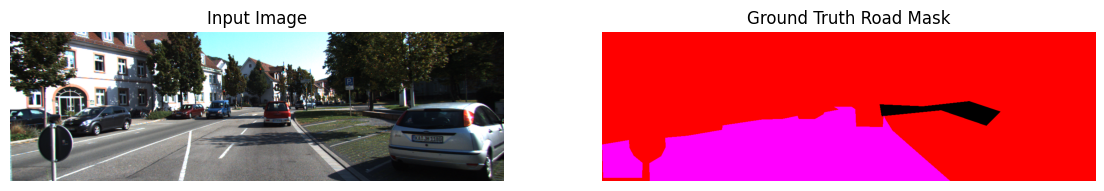

In [33]:
image = cv2.imread(image_paths[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_rgb)
plt.title("Ground Truth Road Mask")
plt.axis("off")

plt.show()

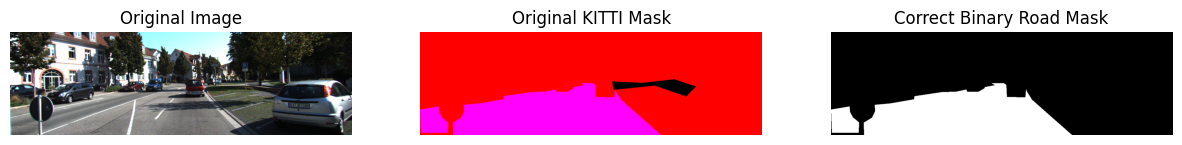

In [34]:
mask = cv2.imread(mask_paths[0])

# Convert BGR to RGB
mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

# Isolate Magenta pixels [255, 0, 255] (Road area)
binary_mask = np.all(mask_rgb == [255, 0, 255], axis=-1).astype(np.float32)

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_paths[0]), cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_rgb)
plt.title("Original KITTI Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(binary_mask, cmap="gray")
plt.title("Binary Road Mask")
plt.axis("off")

plt.show()

In [12]:
IMG_HEIGHT = 256
IMG_WIDTH = 512

In [35]:
def load_image_and_mask(image_path, mask_path):

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load mask
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    # Resize
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT)
    )

    mask = cv2.resize(
        mask,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_NEAREST
    )

    # Normalize image
    image = image.astype(np.float32) / 255.0

    # RGB Magenta = Road
    binary_mask = np.all(
        mask == [255, 0, 255],
        axis=-1
    ).astype(np.float32)

    # Add channel dimension
    binary_mask = np.expand_dims(
        binary_mask,
        axis=-1
    )

    return image, binary_mask

In [36]:
print(np.unique(binary_mask))
print("Road pixels:", np.sum(binary_mask))
print("Total pixels:", binary_mask.size)
print("Road percentage:", np.mean(binary_mask) * 100)

[0. 1.]
Road pixels: 102834.0
Total pixels: 465750
Road percentage: 22.079226


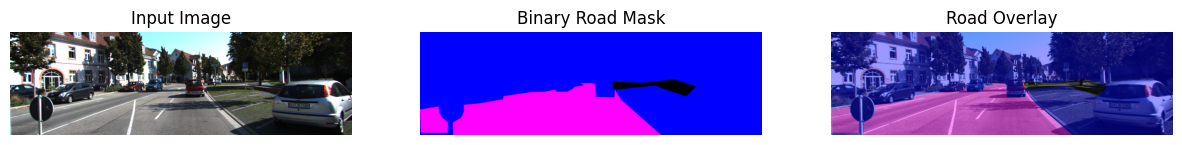

In [37]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Binary Road Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image)
plt.imshow(mask.squeeze(), alpha=0.4, cmap="Reds")
plt.title("Road Overlay")
plt.axis("off")

plt.show()

In [38]:
from sklearn.model_selection import train_test_split

train_image_paths, val_image_paths, train_mask_paths, val_mask_paths = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_image_paths))
print("Validation images:", len(val_image_paths))

Training images: 231
Validation images: 58


In [40]:
def load_data(image_path, mask_path):

    image, mask = tf.numpy_function(
        load_image_and_mask,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )

    image.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
    mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])

    return image, mask

In [41]:
BATCH_SIZE = 4

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, train_mask_paths)
)

train_dataset = train_dataset.map(
    load_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(100)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [42]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_mask_paths)
)

val_dataset = val_dataset.map(
    load_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

In [43]:
from tensorflow.keras import layers, Model


def conv_block(x, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x


def build_unet():

    inputs = layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    # =====================
    # Encoder
    # =====================

    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 512)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # =====================
    # Bottleneck
    # =====================

    c5 = conv_block(p4, 1024)

    # =====================
    # Decoder
    # =====================

    u6 = layers.Conv2DTranspose(
        512,
        2,
        strides=2,
        padding="same"
    )(c5)

    u6 = layers.Concatenate()([u6, c4])
    c6 = conv_block(u6, 512)

    u7 = layers.Conv2DTranspose(
        256,
        2,
        strides=2,
        padding="same"
    )(c6)

    u7 = layers.Concatenate()([u7, c3])
    c7 = conv_block(u7, 256)

    u8 = layers.Conv2DTranspose(
        128,
        2,
        strides=2,
        padding="same"
    )(c7)

    u8 = layers.Concatenate()([u8, c2])
    c8 = conv_block(u8, 128)

    u9 = layers.Conv2DTranspose(
        64,
        2,
        strides=2,
        padding="same"
    )(c8)

    u9 = layers.Concatenate()([u9, c1])
    c9 = conv_block(u9, 64)

    # =====================
    # Output
    # =====================

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c9)

    return Model(inputs, outputs, name="U-Net")

In [44]:
model = build_unet()

model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 512,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 512,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 512,  │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 512,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 256,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 256,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 128, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 256,  │    147,584 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 128, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 128,   │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 128,   │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128,   │      1,024 │ conv2d_23[0][0] 

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [45]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
def dice_coefficient(y_true, y_pred):

    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_pred = tf.reshape(y_pred, [-1])
    y_true = tf.reshape(y_true, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)

    dice = (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )

    return dice

In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        dice_coefficient
    ]
)

In [49]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 70s 793ms/step - accuracy: 0.9139 - dice_coefficient: 0.5956 - loss: 0.2587 - val_accuracy: 0.1739 - val_dice_coefficient: 0.3022 - val_loss: 1.9227
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 572ms/step - accuracy: 0.9472 - dice_coefficient: 0.7194 - loss: 0.1643 - val_accuracy: 0.2084 - val_dice_coefficient: 0.3144 - val_loss: 5.2338
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 33s 550ms/step - accuracy: 0.9568 - dice_coefficient: 0.7653 - loss: 0.1331 - val_accuracy: 0.1893 - val_dice_coefficient: 0.3045 - val_loss: 7.7850
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 33s 558ms/step - accuracy: 0.9598 - dice_coefficient: 0.7884 - loss: 0.1196 - val_accuracy: 0.4828 - val_dice_coefficient: 0.3798 - val_loss: 2.0890
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 563ms/step - accuracy: 0.9677 - dice_coefficient: 0.8232 - loss: 0.0963 - val_accuracy: 0.5875 - val_dice_coefficient: 0.4472 - val_loss: 1.2870
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 33s 558ms/step - accuracy: 

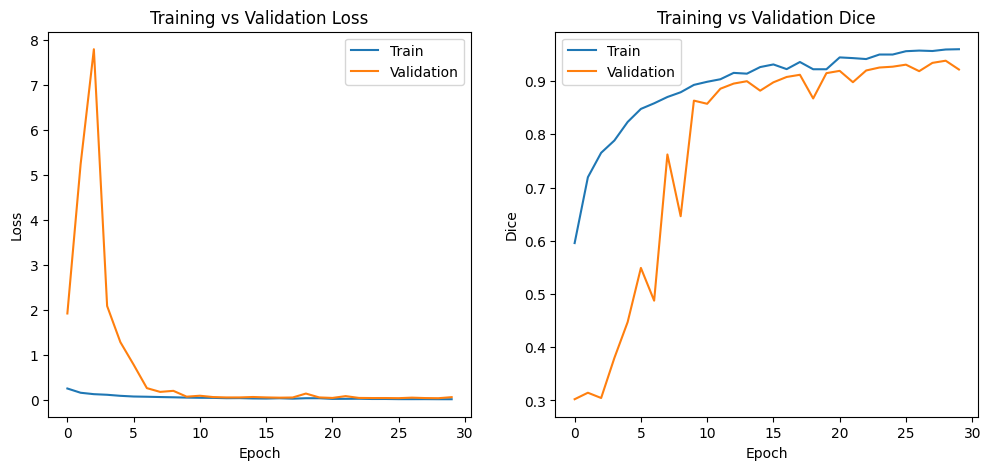

In [51]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])


plt.subplot(1, 2, 2)

plt.plot(history.history["dice_coefficient"])
plt.plot(history.history["val_dice_coefficient"])

plt.title("Training vs Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")

plt.legend(["Train", "Validation"])

plt.show()

In [52]:
test_image, test_mask = load_image_and_mask(
    val_image_paths[0],
    val_mask_paths[0]
)

In [53]:
prediction = model.predict(
    np.expand_dims(test_image, axis=0)
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [54]:
predicted_mask = (prediction > 0.5).astype(np.float32)

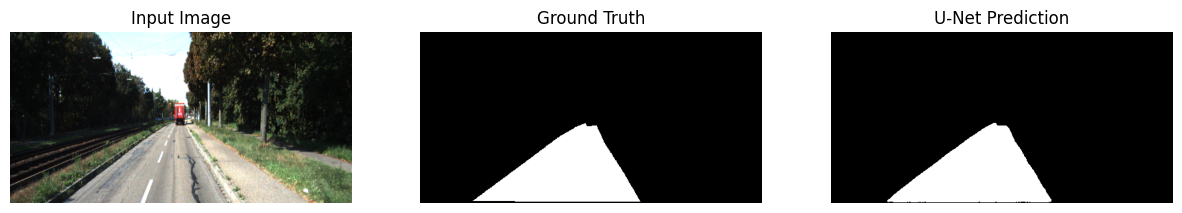

In [55]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(test_mask.squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask.squeeze(), cmap="gray")
plt.title("U-Net Prediction")g
plt.axis("off")

plt.show()

In [56]:
video_path = os.path.join(
    test_data_dir,
    "challenge.mp4"
)

print(video_path)

../input/datasets/sakshaymahna/kittiroadsegmentation/testing/challenge.mp4


In [57]:
def extract_frames(video_path, num_frames=6):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for frame_idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frames.append(frame)

    cap.release()

    return frames

In [58]:
frames = extract_frames(
    video_path,
    num_frames=6
)

print("Number of frames:", len(frames))

for i, frame in enumerate(frames):
    print(i, frame.shape)

Number of frames: 6
0 (720, 1280, 3)
1 (720, 1280, 3)
2 (720, 1280, 3)
3 (720, 1280, 3)
4 (720, 1280, 3)
5 (720, 1280, 3)


In [59]:
def predict_frame(model, frame):

    # Resize frame
    resized = cv2.resize(
        frame,
        (IMG_WIDTH, IMG_HEIGHT)
    )

    # Normalize
    resized = resized.astype(np.float32) / 255.0

    # Add batch dimension
    input_image = np.expand_dims(
        resized,
        axis=0
    )

    # Prediction
    prediction = model.predict(
        input_image,
        verbose=0
    )[0]

    # Convert probability → binary mask
    binary_mask = (
        prediction > 0.5
    ).astype(np.uint8)

    return resized, binary_mask

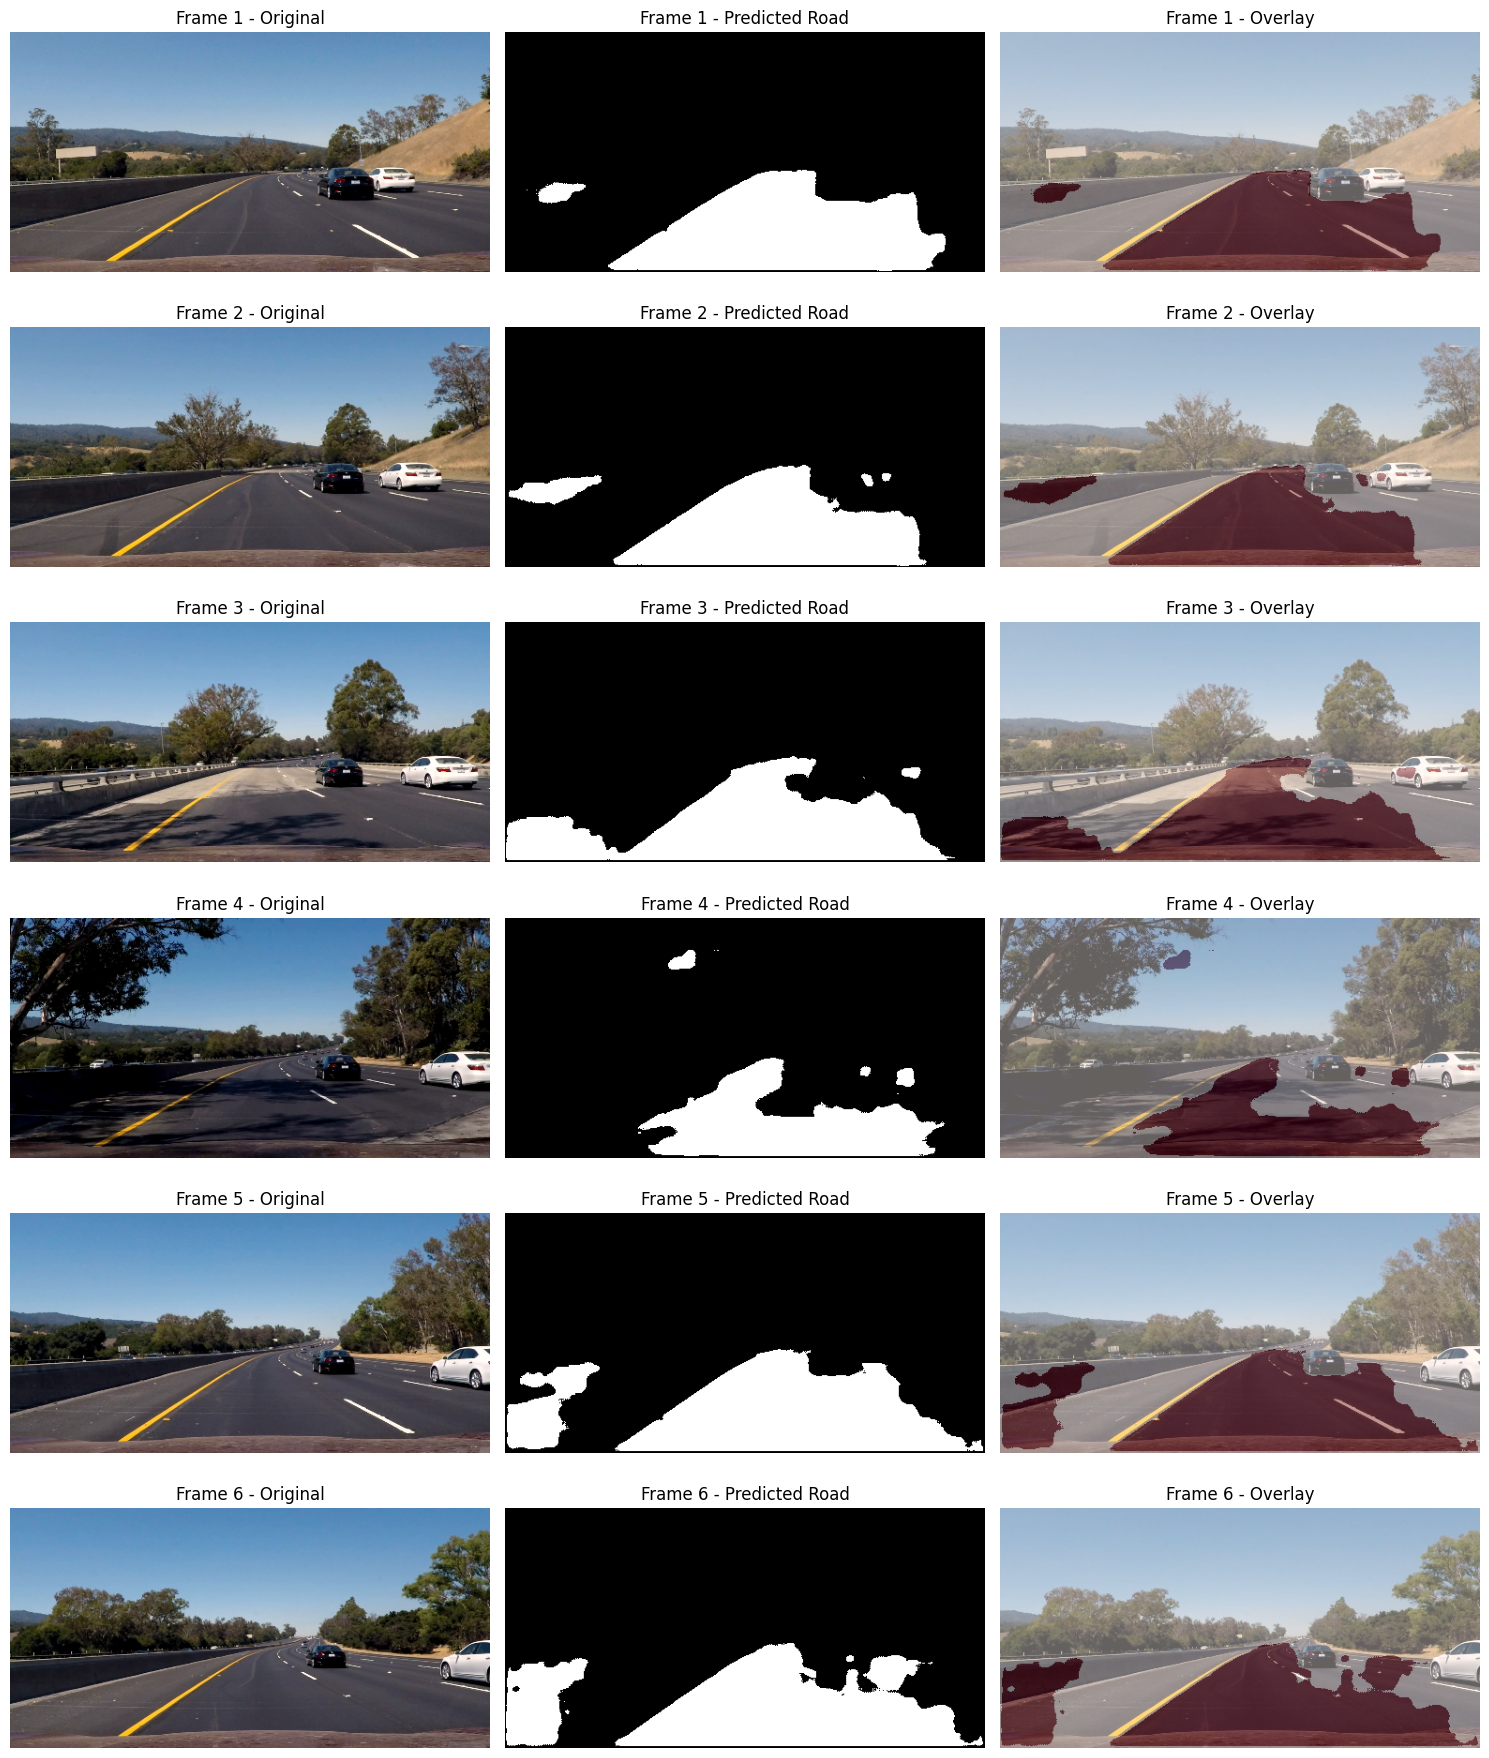

In [60]:
plt.figure(figsize=(15, 18))

for i, frame in enumerate(frames):

    resized_frame, predicted_mask = predict_frame(
        model,
        frame
    )

    # Remove channel dimension
    predicted_mask = predicted_mask.squeeze()

    # --------------------
    # Original frame
    # --------------------

    plt.subplot(len(frames), 3, i * 3 + 1)

    plt.imshow(resized_frame)
    plt.title(f"Frame {i+1} - Original")
    plt.axis("off")

    # --------------------
    # Predicted mask
    # --------------------

    plt.subplot(len(frames), 3, i * 3 + 2)

    plt.imshow(
        predicted_mask,
        cmap="gray"
    )

    plt.title(f"Frame {i+1} - Predicted Road")
    plt.axis("off")

    # --------------------
    # Overlay
    # --------------------

    plt.subplot(len(frames), 3, i * 3 + 3)

    plt.imshow(resized_frame)

    plt.imshow(
        predicted_mask,
        alpha=0.4,
        cmap="Reds"
    )

    plt.title(f"Frame {i+1} - Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()